# Refitting Literature Relations: $M_{\rm{gas}}$-$\lambda$

This section of the project fits scaling relations to literature datasets, in order to compare previous work to our results.

Here we focus on scaling relations between the hot-ICM gas mass of galaxy clusters and groups ($M_{\rm{tot}}$, or $M^{\rm{tot}}_{\Delta}$ within an overdensity radius $R_{\Delta}$) and the cluster/group richness ($\lambda$; a probabilistic measure of the number of galaxies in a cluster/group). We may also refer to $M_{\rm{tot}}$ as $M_{\rm{hy}}$ or $M_{\rm{WL}}$, for hydrostatic mass and weak-lensing mass respectively. Both ostensibly refer to the total halo mass, but are both affected by different physical and practical considerations.

Relation fits are performed using the XGA interface to the R scaling-relation fitting package LIRA, see the paper for full details. This notebook uses data from the following:
* [Rozo et al. (2014)](https://ui.adsabs.harvard.edu/abs/2014ApJ...783...80R/abstract) - **We attempt to recreate their sample by very simply cross-matching [Mantz et al. 2010](https://ui.adsabs.harvard.edu/abs/2010MNRAS.406.1773M/abstract) with SDSS redMaPPer**. This is so we can attempt to refit a $M_{\rm{gas}}$-$\lambda_{\rm{RM}}$ relation made during validation tests of redMaPPer.


## Import Statements

In [2]:
import pandas as pd
import numpy as np
from astropy.units import Quantity
from astropy.cosmology import LambdaCDM

# This adds the directory above to the path, allowing me to import the common functions that I've written in
#  common.py - this just saves me repeating boring code and makes sure its all consistent
import sys
sys.path.insert(0, '..')
from common import rozo_cosmo, rich_norm, mgas_norm

import xga
from xga.relations.fit import scaling_relation_lira

## Normalisation values

These are used when fitting the scaling relations to normalise the data, and are kept the same throughout this entire project:

In [3]:
rich_norm

<Quantity 100.>

In [4]:
mgas_norm

<Quantity 1.e+13 solMass>

## Cosmological models

These are used to calculated the Hubble parameter values applied to some scaling relation parameters - we match the models used by the original analyses, as they will have had effects on the measured property values we are using (small in all likelihood, but still):

### Rozo et al. (2014)

In [5]:
rozo_cosmo

LambdaCDM(name=None, H0=<Quantity 70. km / (Mpc s)>, Om0=0.27, Ode0=0.73, Tcmb0=<Quantity 0. K>, Neff=3.04, m_nu=None, Ob0=0.0)

## Loading data files

All datasets to be refit are included in this repository, so we can load in the required data here.

## Rozo et al. (2014)

Important considerations for this dataset:
* This is an attempted recreation of the Rozo et al. sample, we have cross-matched the SDSS redMaPPer catalogue with the same Mantz et al. work that was the source of gas masses for Rozo et al. - This cross matching is not as sophisticated as was performed in the original paper, as we are not basing scientific conclusions on this re-fitted scaling relation, instead we just match within a 3~arcmin radius.
* The richnesses produced by redMaPPer are rarely given within a particular overdensity radius aperture - so these richnesses will not have been measured within $R_{500}$, which was the aperture Mantz et al. used for their gas masses.
* We remove MACS J2311.5+0338 as (from the Rozo et al. 2014 paper) - "Cluster has distinct NE and SW components. redMaPPer centered on the NE, but X-rays indicate that the SW component is dominant." - and the match showed extremely high gas mass to richness ratio.

In [23]:
rozo_samp = pd.read_csv("../../sample_files/rozo2014_approx.csv")

# Get rid of these
rozo_to_remove = ["MACS J2311.5+0338"]
rozo_samp = rozo_samp[~rozo_samp['name'].isin(rozo_to_remove)].reset_index(drop=True)

rozo_samp.head(6)

,name,mantz_ra,mantz_dec,z,Mg500,Mg500+-,redmapper_ID,redmapper_NAME,redmapper_ra,redmapper_dec,...,MODEL_MAGERR_I,MODEL_MAG_Z,MODEL_MAGERR_Z,ILUM,P_CEN,RA_CEN,DEC_CEN,ID_CEN,PZBINS,PZ
0,Abell 2142,239.587917,27.229167,0.0904,1.59,0.19,1,RMJ155820.0+271400.3,239.583329,27.233413,...,0.002698,13.619685,0.005152,115.149506,"(0.87483835, 0.12514694, 1.3188495E-5, 1.04663...","(239.58333, 239.5554, 239.60272, 239.52678, 23...","(27.233414, 27.248121, 27.229519, 27.274109, 2...","(25404293, 25403990, 25404292, 25404032, 25404...","(0.06894211, 0.07153096, 0.07411982, 0.0767086...","(6.6654225E-6, 1.761979E-4, 0.0023823027, 0.03..."
1,Abell 2244,255.675000,34.056667,0.0989,0.70,0.11,95,RMJ170245.5+340340.1,255.689774,34.061150,...,0.003078,14.984355,0.006282,50.132870,"(0.9427599, 0.056957636, 2.0289236E-4, 6.58954...","(255.68977, 255.62807, 255.62962, 255.65076, 2...","(34.06115, 34.041893, 34.03902, 34.088512, 34....","(8976346, 8976378, 8976379, 8976225, 8976238)","(0.06978572, 0.07248214, 0.075178556, 0.077874...","(1.05270365E-5, 1.9681643E-4, 0.0033546963, 0...."
2,Abell 2034,227.552500,33.512500,0.1130,0.77,0.10,55,RMJ151011.7+332911.3,227.548803,33.486468,...,0.002772,14.009382,0.005505,72.548065,"(0.9750289, 0.013204514, 0.0062975204, 0.00540...","(227.5488, 227.55293, 227.5838, 227.48906, 227...","(33.48647, 33.492496, 33.48598, 33.45417, 33.4...","(22515067, 22515068, 22515381, 22515045, 22514...","(0.09800566, 0.10012887, 0.10225208, 0.1043752...","(1.2159197E-5, 2.4343558E-4, 0.0035838229, 0.0..."
3,Abell 1068,160.185000,39.953611,0.1386,0.43,0.06,1628,RMJ104045.4+395448.6,160.188961,39.913488,...,0.004723,16.091301,0.010649,21.895653,"(0.7930312, 0.19489436, 0.009972161, 0.0020277...","(160.18896, 160.12013, 160.2628, 160.19589, 16...","(39.913486, 40.001034, 39.921654, 39.931065, 3...","(18825022, 22581158, 18825003, 18825024, 22581...","(0.11957392, 0.12192495, 0.12427597, 0.126627,...","(2.8796427E-5, 4.7725954E-4, 0.0059920633, 0.0..."
4,Abell 1914,216.504167,37.826944,0.1712,1.21,0.14,65,RMJ142556.7+374859.2,216.486118,37.816456,...,0.003914,14.864969,0.009584,64.909996,"(0.9656521, 0.03343037, 7.2534755E-4, 1.117608...","(216.48611, 216.51619, 216.51073, 216.48802, 2...","(37.816456, 37.8315, 37.830917, 37.817158, 37....","(22566675, 22566684, 22566676, 22566685, 22566...","(0.14879057, 0.1509631, 0.15313564, 0.15530817...","(3.6913136E-6, 1.07228654E-4, 0.002150382, 0.0..."
5,Abell 963,154.265000,39.047778,0.2060,0.78,0.10,15984,RMJ101703.6+390249.4,154.265148,39.047056,...,0.004134,15.113669,0.008828,28.551146,"(0.95422244, 0.044654746, 8.6539495E-4, 2.0676...","(154.26515, 154.28067, 154.34175, 154.30765, 1...","(39.047054, 39.06059, 39.07769, 39.064766, 39....","(18134507, 18134531, 18134850, 18134599, 18134...","(0.1665876, 0.1704472, 0.17430681, 0.1781664, ...","(1.1396166E-9, 1.7286874E-7, 1.6548576E-5, 7.2..."


In [24]:
rozo_samp.columns

Index(['name', 'mantz_ra', 'mantz_dec', 'z', 'Mg500', 'Mg500+-',
       'redmapper_ID', 'redmapper_NAME', 'redmapper_ra', 'redmapper_dec',
       'Z_LAMBDA', 'Z_LAMBDA_ERR', 'LAMBDA', 'LAMBDA_ERR', 'S', 'Z_SPEC',
       'OBJID', 'IMAG', 'IMAG_ERR', 'MODEL_MAG_U', 'MODEL_MAGERR_U',
       'MODEL_MAG_G', 'MODEL_MAGERR_G', 'MODEL_MAG_R', 'MODEL_MAGERR_R',
       'MODEL_MAG_I', 'MODEL_MAGERR_I', 'MODEL_MAG_Z', 'MODEL_MAGERR_Z',
       'ILUM', 'P_CEN', 'RA_CEN', 'DEC_CEN', 'ID_CEN', 'PZBINS', 'PZ'],
      dtype='object')

Calculating E(z) values for these clusters:

In [25]:
rozo_samp['E'] = rozo_cosmo.efunc(rozo_samp['z'].values)

## Fitting scaling relations

### Rozo et al. (2014)

#### $M^{\rm{gas}}_{500}$-$\lambda_{\rm{RM}}$

In [34]:
# Setting up property variables in astropy quantity objects
rozo_mgas500 = Quantity(rozo_samp[['Mg500', 'Mg500+-', 'Mg500+-']].values*1e+14, 'Msun')
rozo_rich = Quantity(rozo_samp[['LAMBDA', 'LAMBDA_ERR', 'LAMBDA_ERR']].values, '')

rozo_mgas500_rich = scaling_relation_lira(rozo_mgas500[:, 0], rozo_mgas500[:, 1:], rozo_rich[:, 0], rozo_rich[:, 1:], 
                                          mgas_norm, rich_norm, y_name=r"$M^{\rm{gas}}_{500}$", x_name=r"$\lambda_{\rm{RM}}$", 
                                          point_names=rozo_samp['name'].values)
rozo_mgas500_rich.model_colour = 'midnightblue'
rozo_mgas500_rich.author = 'Rozo et al.'
rozo_mgas500_rich.name = r'Rozo et al. $M^{\rm{gas}}_{\rm{500}}$-$\lambda_{\rm{RM}}$'
rozo_mgas500_rich.save("../../outputs/scaling_relations/literature_refits/mgas-richness/rozo2014_mgas500_rich.xgarel")

  |**************************************************| 100%


In [35]:
print("Slope of {v:.3f} ± {e:.3f}\n".format(v=rozo_mgas500_rich.pars[0][0], e=rozo_mgas500_rich.pars[0][1]))
print("Normalisation of {v:.3f} ± {e:.3f}\n".format(v=rozo_mgas500_rich.pars[1][0], e=rozo_mgas500_rich.pars[1][1]))
print("Scatter of {v:.3f} ± {e:.3f}".format(v=rozo_mgas500_rich.scatter_par[0], e=rozo_mgas500_rich.scatter_par[1]))

Slope of 0.669 ± 0.088

Normalisation of 10.415 ± 0.509

Scatter of 0.105 ± 0.018


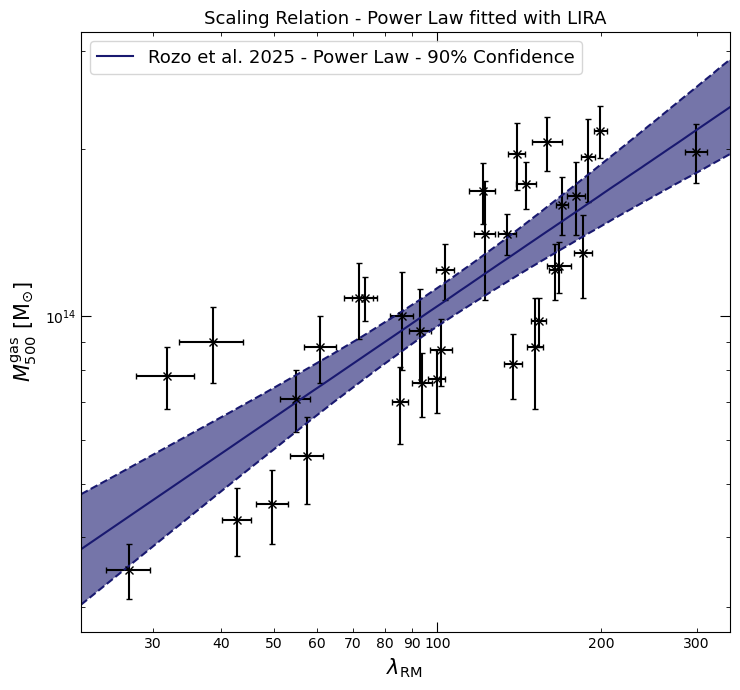

In [36]:
rozo_mgas500_rich.view(figsize=(7.5, 7))

#### Combined contours

In [ ]:
# ( + ).view_corner()